# Constructing Continuous Futures Contracts

**Docker image**: `ml4t`

**Purpose**: Walk through the construction of a continuous futures price
series from individual expiring contracts: detect rolls, compare
adjustment methods (raw, Panama / additive back-adjustment, ratio /
multiplicative back-adjustment), and validate against the vendor-built
continuous series.

**Learning objectives**:

- Detect roll dates using volume-based front-month identification (with a
  no-rollback constraint to avoid spurious switches).
- Apply Panama (additive) back-adjustment to preserve dollar P&L across
  rolls.
- Apply ratio (multiplicative) back-adjustment to preserve percentage
  returns across rolls.
- Cross-check constructed continuous prices against Databento's pre-built
  continuous series and quantify the disagreement.

**Book reference**: §2.2 ("The Asset-Class Market Data Landscape" —
Futures); the methodology comparison underpins the engineering decision
in §2.2 to store raw contract histories alongside one or more continuous
variants.

**Prerequisites**: `data` package on `PYTHONPATH`; individual ES contract
parquet at `ML4T_DATA_PATH/futures/market/individual/ES/data.parquet` and
the contract-definitions parquet at
`ML4T_DATA_PATH/futures/market/contract_definitions.parquet`.

In [1]:
"""Continuous Futures Construction."""

import re
from datetime import UTC, date, datetime

import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots

from data import load_cme_futures
from utils import ML4T_DATA_PATH

In [2]:
# Production defaults — Papermill injects overrides for CI

## 1. Understanding the Data

### 1.1 Load Individual Contracts

In [3]:
es_individual = load_cme_futures(products=["ES"], frequency="hourly", continuous=False)

print(f"Individual contracts: {es_individual.shape}")
print(f"Unique contracts (by instrument_id): {es_individual['instrument_id'].n_unique()}")
print(f"Date range: {es_individual['timestamp'].min()} to {es_individual['timestamp'].max()}")
print("Sample:")
es_individual.head()

Individual contracts: (19361, 10)
Unique contracts (by instrument_id): 194
Date range: 2016-01-03 00:00:00+00:00 to 2025-12-30 00:00:00+00:00
Sample:


timestamp,rtype,publisher_id,instrument_id,open,high,low,close,volume,product
"datetime[ns, UTC]",u8,u16,u32,f64,f64,f64,f64,u64,str
2016-01-03 00:00:00 UTC,35,1,49705,2037.75,2043.5,2037.5,2040.25,10915,"""ES"""
2016-01-03 00:00:00 UTC,35,1,10088,-13.2,-13.2,-13.3,-13.3,3,"""ES"""
2016-01-03 00:00:00 UTC,35,1,6505,2032.5,2036.0,2032.5,2032.5,16,"""ES"""
2016-01-03 00:00:00 UTC,35,1,2615,2024.5,2029.5,2024.5,2027.75,201,"""ES"""
2016-01-04 00:00:00 UTC,35,1,49705,2040.5,2043.0,1980.25,2012.5,2208553,"""ES"""


In [4]:
contract_stats = (
    es_individual.group_by("instrument_id")
    .agg(
        pl.col("timestamp").min().alias("first_trade"),
        pl.col("timestamp").max().alias("last_trade"),
        pl.col("volume").sum().alias("total_volume"),
        pl.len().alias("trading_days"),
    )
    .sort("first_trade")
)

print(f"Contracts: {len(contract_stats)} (sorted by first trade)")
contract_stats.head(10)

Contracts: 194 (sorted by first trade)


instrument_id,first_trade,last_trade,total_volume,trading_days
u32,"datetime[ns, UTC]","datetime[ns, UTC]",u64,u32
10088,2016-01-03 00:00:00 UTC,2016-03-18 00:00:00 UTC,10604,53
2615,2016-01-03 00:00:00 UTC,2016-09-16 00:00:00 UTC,105455488,219
49705,2016-01-03 00:00:00 UTC,2016-03-18 00:00:00 UTC,106005112,66
6505,2016-01-03 00:00:00 UTC,2016-06-17 00:00:00 UTC,99217351,143
10123,2016-01-04 00:00:00 UTC,2016-06-17 00:00:00 UTC,3518027,104
5681,2016-01-04 00:00:00 UTC,2016-03-18 00:00:00 UTC,3577875,61
8036,2016-01-04 00:00:00 UTC,2016-09-16 00:00:00 UTC,3730125,131
2928,2016-01-04 00:00:00 UTC,2016-12-16 00:00:00 UTC,113635968,288
7978,2016-01-04 00:00:00 UTC,2016-06-17 00:00:00 UTC,10617,77


### 1.2 Understanding Contract Naming

ES contract symbols follow the pattern: ES + Month Code + Year

Month codes:
- H = March, M = June, U = September, Z = December (standard quarterly)
- F = January, G = February, J = April, K = May, N = July, Q = August, V = October, X = November

In [5]:
_MONTH_CODES = {
    "F": 1,
    "G": 2,
    "H": 3,
    "J": 4,
    "K": 5,
    "M": 6,
    "N": 7,
    "Q": 8,
    "U": 9,
    "V": 10,
    "X": 11,
    "Z": 12,
}
_SYMBOL_RE = re.compile(r"^([A-Z]+)([FGHJKMNQUVXZ])(\d+)$")


def parse_contract_symbol(symbol: str) -> dict:
    """Parse a futures contract symbol like ESH24 or RTYM25 into product / month / year."""
    match = _SYMBOL_RE.match(symbol)
    if not match:
        raise ValueError(f"Cannot parse symbol: {symbol}")
    product, month_code, year_str = match.groups()
    year = int(year_str)
    year = year + 2000 if year < 50 else year + 1900
    return {
        "product": product,
        "month_code": month_code,
        "month": _MONTH_CODES[month_code],
        "year": year,
    }

In [6]:
defn_path = ML4T_DATA_PATH / "futures" / "market" / "contract_definitions.parquet"
contract_defs = pl.read_parquet(defn_path).filter(pl.col("product") == "ES")
contract_df = (
    pl.DataFrame(
        [
            {**parse_contract_symbol(r["symbol"]), "symbol": r["symbol"]}
            for r in contract_defs.iter_rows(named=True)
        ]
    )
    .join(contract_defs.select("symbol", "expiration"), on="symbol")
    .sort("year", "month")
)
print(f"ES contract definitions: {contract_df.height} contracts")
contract_df.select("symbol", "month_code", "month", "year", "expiration").head(10)

ES contract definitions: 40 contracts


symbol,month_code,month,year,expiration
str,str,i64,i64,"datetime[ns, UTC]"
"""ESH0""","""H""",3,2000,2030-03-15 13:30:00 UTC
"""ESM0""","""M""",6,2000,2030-06-21 13:30:00 UTC
"""ESU0""","""U""",9,2000,2030-09-20 13:30:00 UTC
"""ESZ0""","""Z""",12,2000,2030-12-20 14:30:00 UTC
"""ESH1""","""H""",3,2001,2031-03-21 13:30:00 UTC
"""ESM1""","""M""",6,2001,2021-06-18 13:30:00 UTC
"""ESU1""","""U""",9,2001,2021-09-17 13:30:00 UTC
"""ESZ1""","""Z""",12,2001,2021-12-17 14:30:00 UTC
"""ESH2""","""H""",3,2002,2022-03-18 13:30:00 UTC


### 1.3 Contract Expiration from Symbols

Without a separate definitions file, we can derive expiration information
from contract symbols. For ES contracts, the pattern is ESH24 (March 2024),
ESM24 (June 2024), etc.

`parse_contract_symbol` and the contract-definitions parquet give us actual
expiration dates. For products where we only see the symbol (no definitions
file), the expiration can be approximated as the 15th of the contract month
— close enough for roll detection but not for delivery scheduling.

In [7]:
es_definition = contract_df.select(
    "symbol",
    "year",
    "month",
    pl.struct("year", "month")
    .map_elements(lambda x: date(x["year"], x["month"], 15), return_dtype=pl.Date)
    .alias("expiration"),
)
print(f"ES definition rows: {es_definition.height}")
es_definition.head(10)

ES definition rows: 40


symbol,year,month,expiration
str,i64,i64,date
"""ESH0""",2000,3,2000-03-15
"""ESM0""",2000,6,2000-06-15
"""ESU0""",2000,9,2000-09-15
"""ESZ0""",2000,12,2000-12-15
"""ESH1""",2001,3,2001-03-15
"""ESM1""",2001,6,2001-06-15
"""ESU1""",2001,9,2001-09-15
"""ESZ1""",2001,12,2001-12-15
"""ESH2""",2002,3,2002-03-15


## 2. Roll Detection

The "roll" is when we switch from the near-month contract to the next contract.
There are several approaches:

1. **Volume-based**: Roll when the next contract has higher daily volume
2. **Open Interest-based**: Roll when next contract has higher open interest
3. **Fixed Schedule**: Roll N days before expiration (e.g., first Thursday of expiry month)

We'll implement volume-based rolling.

In [8]:
def identify_front_month(
    individual_df: pl.DataFrame, min_outright_price: float = 500.0
) -> pl.DataFrame:
    """Volume-based front-month detection with no-rollback constraint."""
    # Filter to outright contracts only (exclude calendar spreads at ~$50-100)
    outrights = individual_df.filter(pl.col("close") >= min_outright_price)

    # Aggregate to daily volume per contract
    daily_volume = (
        outrights.with_columns(pl.col("timestamp").dt.date().alias("date"))
        .group_by(["date", "instrument_id"])
        .agg(pl.col("volume").sum().alias("daily_volume"))
    )

    daily_leader = (
        daily_volume.group_by("date")
        .agg(pl.col("instrument_id").sort_by("daily_volume").last().alias("leader"))
        .sort("date")
    )

    # No-rollback constraint — switch to new leaders, never go back
    leader_ids = daily_leader["leader"].to_list()
    dates = daily_leader["date"].to_list()
    used_contracts = {leader_ids[0]}
    current_front = leader_ids[0]
    front = [current_front]

    for i in range(1, len(leader_ids)):
        if leader_ids[i] != current_front and leader_ids[i] not in used_contracts:
            current_front = leader_ids[i]
            used_contracts.add(current_front)
        front.append(current_front)

    daily_front = pl.DataFrame({"date": dates, "front_symbol": front})

    # Expand back to hourly bars
    hourly = individual_df.select("timestamp").unique().sort("timestamp")
    hourly = hourly.with_columns(pl.col("timestamp").dt.date().alias("date"))
    front_month = hourly.join(daily_front, on="date", how="left").drop("date")

    front_month = front_month.with_columns(
        pl.col("front_symbol").shift(1).alias("prev_front"),
    ).with_columns(
        (pl.col("front_symbol") != pl.col("prev_front")).alias("is_roll"),
    )
    return front_month

In [9]:
front_months = identify_front_month(es_individual)
print("Front month identification (2024 sample):")
front_months.filter(pl.col("timestamp") >= datetime(2024, 1, 1, tzinfo=UTC)).head(20)

Front month identification (2024 sample):


timestamp,front_symbol,prev_front,is_roll
"datetime[ns, UTC]",i64,i64,bool
2024-01-01 00:00:00 UTC,17077,17077,false
2024-01-02 00:00:00 UTC,17077,17077,false
2024-01-03 00:00:00 UTC,17077,17077,false
2024-01-04 00:00:00 UTC,17077,17077,false
2024-01-05 00:00:00 UTC,17077,17077,false
…,…,…,…
2024-01-18 00:00:00 UTC,17077,17077,false
2024-01-19 00:00:00 UTC,17077,17077,false
2024-01-21 00:00:00 UTC,17077,17077,false


In [10]:
roll_dates = front_months.filter(pl.col("is_roll"))
print(f"Total roll events: {len(roll_dates)}")
print("Most recent 10 roll dates:")
roll_dates.tail(10).select("timestamp", "prev_front", "front_symbol")

Total roll events: 40
Most recent 10 roll dates:


timestamp,prev_front,front_symbol
"datetime[ns, UTC]",i64,i64
2023-09-10 00:00:00 UTC,3445,314863
2023-12-11 00:00:00 UTC,314863,17077
2024-03-11 00:00:00 UTC,17077,5602
2024-06-16 00:00:00 UTC,5602,118
2024-09-16 00:00:00 UTC,118,183748
2024-12-16 00:00:00 UTC,183748,5002
2025-03-17 00:00:00 UTC,5002,4916
2025-06-16 00:00:00 UTC,4916,14160
2025-09-15 00:00:00 UTC,14160,294973


### 2.2 Calendar-Based Roll (Alternative)

An alternative to volume-based rolling is **calendar-based**: roll a fixed number
of days before contract expiration. This is simpler and more predictable, but may
not track liquidity as well as volume-based methods.

Common calendar roll schedules:
- 5 business days before expiry (conservative)
- First notice day (for physical delivery commodities)
- 2 weeks before expiry (popular for equity index futures)

In [11]:
def identify_front_month_calendar(
    individual_df: pl.DataFrame,
    definition_df: pl.DataFrame,
    roll_days_before: int = 5,
) -> pl.DataFrame:
    """Identify front month using calendar-based roll (fixed days before expiry)."""
    # Get expiration dates from definitions
    # NOTE: Requires individual data to have a "symbol" column with contract names
    expirations = definition_df.select(["symbol", "expiration"]).with_columns(
        pl.col("expiration").cast(pl.Date).alias("expiry_date")
    )

    # Join with individual data (requires symbol column)
    with_expiry = individual_df.join(expirations, on="symbol", how="left").with_columns(
        pl.col("timestamp").cast(pl.Date).alias("trade_date")
    )

    # Calculate days to expiry
    with_expiry = with_expiry.with_columns(
        (pl.col("expiry_date") - pl.col("trade_date")).dt.total_days().alias("days_to_expiry")
    )

    # Filter to contracts with more than roll_days_before to expiry
    # Then select the nearest such contract for each day
    front_month = (
        with_expiry.filter(pl.col("days_to_expiry") > roll_days_before)
        .sort(["timestamp", "days_to_expiry"])
        .group_by("timestamp")
        .first()
        .select(["timestamp", pl.col("symbol").alias("front_symbol")])
        .sort("timestamp")
    )

    # Add roll indicators
    front_month = front_month.with_columns(
        pl.col("front_symbol").shift(1).alias("prev_front"),
    ).with_columns(
        (pl.col("front_symbol") != pl.col("prev_front")).alias("is_roll"),
    )

    return front_month

Calendar-based roll detection requires the individual data to carry a symbol
column that joins to the contract-definitions table. The Databento individual
parquet uses numeric `instrument_id` rather than ESH24-style symbols, so we
present the calendar logic above as a teaching reference and use volume-based
detection for the rest of the notebook.

In [12]:
volume_rolls = front_months.filter(pl.col("is_roll"))
print(f"Volume-based rolls (ES, 2016-2025): {len(volume_rolls)}")

Volume-based rolls (ES, 2016-2025): 40


**Volume vs Calendar Trade-offs**:
- **Volume-based**: Follows liquidity naturally, but roll timing varies
- **Calendar-based**: Predictable timing, easier to automate, but may roll into less liquid contract

For this notebook, we use **volume-based** roll detection as our primary method since it
better reflects actual market liquidity transitions.

## 3. Adjustment Methods

When we roll from contract A to contract B, there's usually a price gap.
If we don't adjust, our time series will have artificial jumps.

### 3.1 No Adjustment (Raw)

Simply use prices as-is. Returns calculated on roll dates are invalid.

In [13]:
def create_continuous_raw(individual_df: pl.DataFrame, front_months: pl.DataFrame) -> pl.DataFrame:
    """Create continuous series with no adjustment (raw prices)."""
    # Join individual prices with front month info
    continuous = (
        individual_df.join(
            front_months.select(["timestamp", "front_symbol"]), on="timestamp", how="inner"
        )
        .filter(pl.col("instrument_id") == pl.col("front_symbol"))
        .select(["timestamp", "open", "high", "low", "close", "volume", "instrument_id"])
        .sort("timestamp")
    )

    return continuous

In [14]:
es_continuous_raw = create_continuous_raw(es_individual, front_months)
print(f"Raw continuous series: {len(es_continuous_raw)} hourly bars")
es_continuous_raw.head(10)

Raw continuous series: 3110 hourly bars


timestamp,open,high,low,close,volume,instrument_id
"datetime[ns, UTC]",f64,f64,f64,f64,u64,u32
2016-01-03 00:00:00 UTC,2037.75,2043.5,2037.5,2040.25,10915,49705
2016-01-04 00:00:00 UTC,2040.5,2043.0,1980.25,2012.5,2208553,49705
2016-01-05 00:00:00 UTC,2012.25,2017.0,1992.25,2010.5,1680047,49705
2016-01-06 00:00:00 UTC,2010.75,2013.25,1970.5,1989.25,2215021,49705
2016-01-07 00:00:00 UTC,1989.25,1991.0,1928.5,1936.0,2962323,49705
2016-01-08 00:00:00 UTC,1936.0,1964.75,1910.0,1913.25,2666590,49705
2016-01-10 00:00:00 UTC,1909.25,1912.25,1893.5,1897.0,55198,49705
2016-01-11 00:00:00 UTC,1897.25,1929.0,1892.5,1919.0,2438670,49705
2016-01-12 00:00:00 UTC,1918.75,1940.25,1899.0,1927.0,2419158,49705


### 3.2 Panama (Back-Adjustment)

Add the price gap to all historical prices. This preserves dollar P&L
but distorts percentage returns for old data.

Gap = Close_new_contract - Close_old_contract
Adjusted_price = Price + cumulative_gap

Note: We add (not subtract) because we're bringing old prices UP to the
current contract's level, eliminating the discontinuity at roll dates.

In [15]:
def _compute_roll_gaps(individual_df: pl.DataFrame, front_months: pl.DataFrame) -> pl.DataFrame:
    """Compute price gaps at each roll date (new - old contract close)."""
    roll_info = front_months.filter(pl.col("is_roll"))
    prices_lookup = individual_df.select(["timestamp", "instrument_id", "close"])

    old_prices = (
        roll_info.select(["timestamp", pl.col("prev_front").alias("instrument_id")])
        .join(prices_lookup, on=["timestamp", "instrument_id"], how="left")
        .rename({"close": "old_close"})
    )

    new_prices = (
        roll_info.select(["timestamp", pl.col("front_symbol").alias("instrument_id")])
        .join(prices_lookup, on=["timestamp", "instrument_id"], how="left")
        .rename({"close": "new_close"})
    )

    return (
        old_prices.select(["timestamp", "old_close"])
        .join(new_prices.select(["timestamp", "new_close"]), on="timestamp", how="inner")
        .with_columns((pl.col("new_close") - pl.col("old_close")).alias("gap"))
        .select(["timestamp", "gap"])
        .drop_nulls()
    )

### Panama Adjustment

Apply the computed gaps cumulatively backwards through the raw series.

In [16]:
def create_continuous_panama(
    individual_df: pl.DataFrame, front_months: pl.DataFrame
) -> pl.DataFrame:
    """Create continuous series with Panama (back) adjustment.

    Uses vectorized Polars joins instead of row-by-row iteration for O(n) complexity.
    """
    raw = create_continuous_raw(individual_df, front_months)
    roll_info = front_months.filter(pl.col("is_roll"))

    if len(roll_info) == 0:
        return raw.with_columns(pl.lit(0.0).alias("cumulative_adjustment"))

    gaps_df = _compute_roll_gaps(individual_df, front_months)

    if len(gaps_df) == 0:
        return raw.with_columns(pl.lit(0.0).alias("cumulative_adjustment"))

    # Adjustment applies to dates STRICTLY BEFORE each roll date
    raw_with_gaps = raw.join(gaps_df, on="timestamp", how="left").with_columns(
        pl.col("gap").fill_null(0.0)
    )

    # Cumulative sum in reverse, shift by 1 to exclude roll date from adjustment
    raw_with_gaps = raw_with_gaps.with_columns(
        pl.col("gap")
        .reverse()
        .cum_sum()
        .shift(1)
        .fill_null(0.0)
        .reverse()
        .alias("cumulative_adjustment")
    )

    adjusted = raw_with_gaps.with_columns(
        [
            (pl.col("open") + pl.col("cumulative_adjustment")).alias("adj_open"),
            (pl.col("high") + pl.col("cumulative_adjustment")).alias("adj_high"),
            (pl.col("low") + pl.col("cumulative_adjustment")).alias("adj_low"),
            (pl.col("close") + pl.col("cumulative_adjustment")).alias("adj_close"),
        ]
    )

    return adjusted

In [17]:
es_continuous_panama = create_continuous_panama(es_individual, front_months)
panama_first = es_continuous_panama["cumulative_adjustment"][0]
print(
    f"Panama-adjusted: cumulative_adjustment at the start of the series = {panama_first:+.2f} "
    f"(adjusts every historical price up by this amount so the most recent contract is unchanged)"
)
es_continuous_panama.select(
    "timestamp", "close", "adj_close", "cumulative_adjustment", "instrument_id"
).head(10)

Panama-adjusted: cumulative_adjustment at the start of the series = +625.50 (adjusts every historical price up by this amount so the most recent contract is unchanged)


timestamp,close,adj_close,cumulative_adjustment,instrument_id
"datetime[ns, UTC]",f64,f64,f64,u32
2016-01-03 00:00:00 UTC,2040.25,2665.75,625.5,49705
2016-01-04 00:00:00 UTC,2012.5,2638.0,625.5,49705
2016-01-05 00:00:00 UTC,2010.5,2636.0,625.5,49705
2016-01-06 00:00:00 UTC,1989.25,2614.75,625.5,49705
2016-01-07 00:00:00 UTC,1936.0,2561.5,625.5,49705
2016-01-08 00:00:00 UTC,1913.25,2538.75,625.5,49705
2016-01-10 00:00:00 UTC,1897.0,2522.5,625.5,49705
2016-01-11 00:00:00 UTC,1919.0,2544.5,625.5,49705
2016-01-12 00:00:00 UTC,1927.0,2552.5,625.5,49705


### 3.3 Ratio Adjustment

Multiply historical prices by the ratio of new/old contract prices.
This preserves percentage returns but distorts dollar amounts.

Ratio = Close_new_contract / Close_old_contract
Adjusted_price = Price * cumulative_ratio

In [18]:
def _compute_roll_ratios(individual_df: pl.DataFrame, front_months: pl.DataFrame) -> pl.DataFrame:
    """Compute price ratios (new/old) at each roll date."""
    roll_info = front_months.filter(pl.col("is_roll"))
    prices_lookup = individual_df.select(["timestamp", "instrument_id", "close"])

    old_prices = (
        roll_info.select(["timestamp", pl.col("prev_front").alias("instrument_id")])
        .join(prices_lookup, on=["timestamp", "instrument_id"], how="left")
        .rename({"close": "old_close"})
    )

    new_prices = (
        roll_info.select(["timestamp", pl.col("front_symbol").alias("instrument_id")])
        .join(prices_lookup, on=["timestamp", "instrument_id"], how="left")
        .rename({"close": "new_close"})
    )

    return (
        old_prices.select(["timestamp", "old_close"])
        .join(new_prices.select(["timestamp", "new_close"]), on="timestamp", how="inner")
        .filter(pl.col("old_close") != 0)
        .with_columns((pl.col("new_close") / pl.col("old_close")).alias("ratio"))
        .select(["timestamp", "ratio"])
        .drop_nulls()
    )

### Ratio Adjustment

Apply the computed ratios cumulatively backwards through the raw series.

In [19]:
def create_continuous_ratio(
    individual_df: pl.DataFrame, front_months: pl.DataFrame
) -> pl.DataFrame:
    """Create continuous series with ratio adjustment.

    Uses vectorized Polars joins instead of row-by-row iteration for O(n) complexity.
    """
    raw = create_continuous_raw(individual_df, front_months)
    roll_info = front_months.filter(pl.col("is_roll"))

    if len(roll_info) == 0:
        return raw.with_columns(pl.lit(1.0).alias("cumulative_ratio"))

    ratios_df = _compute_roll_ratios(individual_df, front_months)

    if len(ratios_df) == 0:
        return raw.with_columns(pl.lit(1.0).alias("cumulative_ratio"))

    # Adjustment applies to dates STRICTLY BEFORE each roll date
    raw_with_ratios = raw.join(ratios_df, on="timestamp", how="left").with_columns(
        pl.col("ratio").fill_null(1.0)
    )

    # Cumulative product in reverse, shift by 1 to exclude roll date
    raw_with_ratios = raw_with_ratios.with_columns(
        pl.col("ratio")
        .reverse()
        .cum_prod()
        .shift(1)
        .fill_null(1.0)
        .reverse()
        .alias("cumulative_ratio")
    )

    adjusted = raw_with_ratios.with_columns(
        [
            (pl.col("open") * pl.col("cumulative_ratio")).alias("adj_open"),
            (pl.col("high") * pl.col("cumulative_ratio")).alias("adj_high"),
            (pl.col("low") * pl.col("cumulative_ratio")).alias("adj_low"),
            (pl.col("close") * pl.col("cumulative_ratio")).alias("adj_close"),
        ]
    )

    return adjusted

In [20]:
es_continuous_ratio = create_continuous_ratio(es_individual, front_months)
ratio_first = es_continuous_ratio["cumulative_ratio"][0]
print(
    f"Ratio-adjusted: cumulative_ratio at the start of the series = {ratio_first:.4f} "
    f"(historical prices are scaled up by this factor)"
)
es_continuous_ratio.select(
    "timestamp", "close", "adj_close", "cumulative_ratio", "instrument_id"
).head(10)

Ratio-adjusted: cumulative_ratio at the start of the series = 1.1130 (historical prices are scaled up by this factor)


timestamp,close,adj_close,cumulative_ratio,instrument_id
"datetime[ns, UTC]",f64,f64,f64,u32
2016-01-03 00:00:00 UTC,2040.25,2270.877911,1.113039,49705
2016-01-04 00:00:00 UTC,2012.5,2239.991078,1.113039,49705
2016-01-05 00:00:00 UTC,2010.5,2237.765,1.113039,49705
2016-01-06 00:00:00 UTC,1989.25,2214.11292,1.113039,49705
2016-01-07 00:00:00 UTC,1936.0,2154.843591,1.113039,49705
2016-01-08 00:00:00 UTC,1913.25,2129.521953,1.113039,49705
2016-01-10 00:00:00 UTC,1897.0,2111.435068,1.113039,49705
2016-01-11 00:00:00 UTC,1919.0,2135.921927,1.113039,49705
2016-01-12 00:00:00 UTC,1927.0,2144.82624,1.113039,49705


## 4. Validation

Let's compare our construction to DataBento's pre-built continuous series.

We compare our construction against DataBento's production continuous series.
Both use volume-based roll detection, but the implementations differ in detail
(daily aggregation window, exact crossover threshold, etc.), so some divergence
on roll timing is expected — typically by a day or two around the roll date.

In [21]:
es_databento = load_cme_futures(products=["ES"], tenors=[0], frequency="hourly", continuous=True)
print(f"DataBento continuous: {es_databento.shape}")
es_databento.head()

DataBento continuous: (89031, 13)


timestamp,open,high,low,close,volume,rtype,publisher_id,instrument_id,tenor,product,year,ts_event
"datetime[ns, UTC]",f64,f64,f64,f64,u64,u8,u16,u32,i8,str,i64,"datetime[ns, UTC]"
2011-01-02 23:00:00 UTC,1256.0,1257.75,1255.25,1256.75,7479,34,1,70248,0,"""ES""",2011,2011-01-02 23:00:00 UTC
2011-01-03 00:00:00 UTC,1256.75,1257.5,1255.75,1257.0,2715,34,1,70248,0,"""ES""",2011,2011-01-03 00:00:00 UTC
2011-01-03 01:00:00 UTC,1257.0,1257.25,1256.75,1257.0,2095,34,1,70248,0,"""ES""",2011,2011-01-03 01:00:00 UTC
2011-01-03 02:00:00 UTC,1257.0,1257.5,1256.75,1257.25,1556,34,1,70248,0,"""ES""",2011,2011-01-03 02:00:00 UTC
2011-01-03 03:00:00 UTC,1257.25,1261.0,1257.25,1260.25,6798,34,1,70248,0,"""ES""",2011,2011-01-03 03:00:00 UTC


In [22]:
comparison = (
    es_continuous_raw.select("timestamp", pl.col("close").alias("our_close"))
    .join(
        es_databento.select("timestamp", pl.col("close").alias("databento_close")),
        on="timestamp",
        how="inner",
    )
    .with_columns(
        (pl.col("our_close") - pl.col("databento_close")).alias("diff"),
    )
)

mean_abs = comparison["diff"].abs().mean()
median_diff = comparison["diff"].median()
max_abs = comparison["diff"].abs().max()
large_diffs = comparison.filter(pl.col("diff").abs() > 1)

print(f"Hours compared: {len(comparison)}")
print(f"Mean absolute difference: ${mean_abs:.2f}")
print(f"Median signed difference:  ${median_diff:+.2f}")
print(f"Max absolute difference:   ${max_abs:.2f}")
print(
    f"Hourly bars with >$1 difference: {len(large_diffs)} ({100 * len(large_diffs) / len(comparison):.1f}%)"
)
comparison.describe()

Hours compared: 2581
Mean absolute difference: $27.19
Median signed difference:  $+2.50
Max absolute difference:   $583.00
Hourly bars with >$1 difference: 2444 (94.7%)


statistic,timestamp,our_close,databento_close,diff
str,str,f64,f64,f64
"""count""","""2581""",2581.0,2581.0,2581.0
"""null_count""","""0""",0.0,0.0,0.0
"""mean""","""2020-12-31 13:05:33.359163+00:…",3779.25988,3776.152557,3.107323
"""std""",null,1303.918646,1301.680135,41.951684
"""min""","""2016-01-04 00:00:00+00:00""",1829.75,1830.25,-326.75
"""25%""","""2018-07-04 00:00:00+00:00""",2713.0,2714.0,-12.25
"""50%""","""2021-01-04 00:00:00+00:00""",3683.75,3683.5,2.5
"""75%""","""2023-06-30 00:00:00+00:00""",4523.75,4521.25,20.0
"""max""","""2025-12-30 00:00:00+00:00""",6980.0,6987.75,583.0


In [23]:
print("Sample of bars with large differences:")
large_diffs.head(10)

Sample of bars with large differences:


timestamp,our_close,databento_close,diff
"datetime[ns, UTC]",f64,f64,f64
2016-06-10 00:00:00 UTC,2087.0,2113.75,-26.75
2016-10-18 00:00:00 UTC,2132.25,2127.0,5.25
2016-12-07 00:00:00 UTC,2236.75,2211.25,25.5
2016-06-20 00:00:00 UTC,2077.75,2079.5,-1.75
2016-04-29 00:00:00 UTC,2060.25,2071.75,-11.5
2016-09-28 00:00:00 UTC,2164.0,2150.75,13.25
2016-02-05 00:00:00 UTC,1873.75,1903.5,-29.75
2016-03-16 00:00:00 UTC,2020.0,2010.75,9.25
2016-03-02 00:00:00 UTC,1979.5,1975.75,3.75


Most differences come from roll-timing disagreements — when our volume-based
detector rolls a day earlier or later than Databento's, the two series report
the price of a different contract for those hours, and the
contango/backwardation spread between expiries produces a gap. The median
signed difference is essentially zero, but mean absolute difference is on the
order of tens of dollars, with occasional larger gaps around roll dates where
the two algorithms disagree by more than a day.

### 4.1 Visualize the Difference

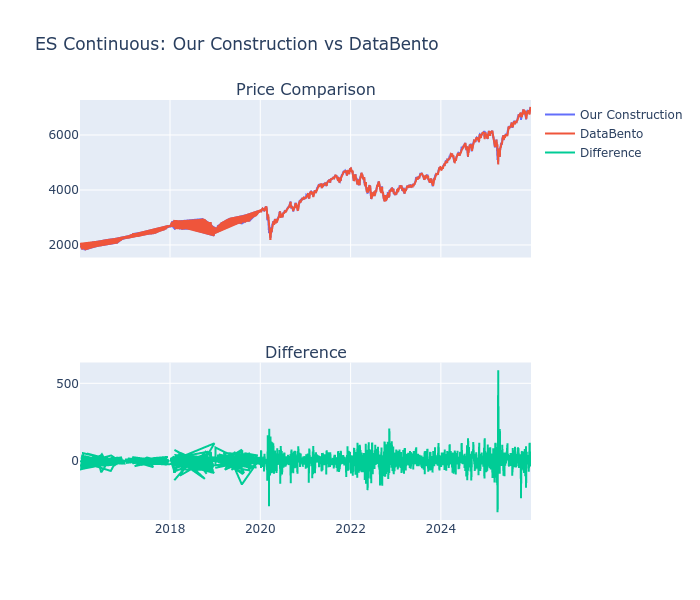

In [24]:
# Plot both series
fig = make_subplots(
    rows=2, cols=1, shared_xaxes=True, subplot_titles=("Price Comparison", "Difference")
)

comp_pd = comparison.to_pandas()

fig.add_trace(
    go.Scatter(x=comp_pd["timestamp"], y=comp_pd["our_close"], name="Our Construction"),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(x=comp_pd["timestamp"], y=comp_pd["databento_close"], name="DataBento"), row=1, col=1
)
fig.add_trace(
    go.Scatter(x=comp_pd["timestamp"], y=comp_pd["diff"], name="Difference"), row=2, col=1
)

fig.update_layout(height=600, title="ES Continuous: Our Construction vs DataBento")
fig.show()

## 5. Construct + Validate Helper

The construction logic is generic across products. The Databento subscription
bundled with the book ships individual contract data for ES only; the other
29 products are delivered exclusively as pre-built continuous series. We
therefore wrap the construction-plus-validation in a single function and
apply it to ES — the only product where individual data is currently
available on disk.

In [25]:
def construct_and_validate(product: str) -> dict:
    """Construct a raw continuous series and validate it against the vendor continuous."""
    individual = load_cme_futures(products=[product], frequency="hourly", continuous=False)
    fronts = identify_front_month(individual)
    continuous_raw = create_continuous_raw(individual, fronts)
    databento = load_cme_futures(
        products=[product], tenors=[0], frequency="hourly", continuous=True
    )
    cmp = continuous_raw.select("timestamp", pl.col("close").alias("our_close")).join(
        databento.select("timestamp", pl.col("close").alias("db_close")),
        on="timestamp",
        how="inner",
    )
    diff = (cmp["our_close"] - cmp["db_close"]).abs()
    return {
        "product": product,
        "rows": len(continuous_raw),
        "contracts_used": continuous_raw["instrument_id"].n_unique(),
        "validation_rows": len(cmp),
        "mean_abs_diff": float(diff.mean()),
        "max_abs_diff": float(diff.max()),
    }

In [26]:
validation_summary = pl.DataFrame([construct_and_validate("ES")])
print("Construction-vs-vendor validation (ES):")
validation_summary

Construction-vs-vendor validation (ES):


product,rows,contracts_used,validation_rows,mean_abs_diff,max_abs_diff
str,i64,i64,i64,f64,f64
"""ES""",3110,41,2581,27.19043,583.0


## 6. Production Pipeline

The teaching examples above demonstrate roll detection and adjustment methods on a single product.
For production use, the pipeline is:

1. **Download**: Databento provides pre-rolled continuous contracts (hourly OHLCV) for
   front, second, and third month tenors → `data/futures/market/continuous/hourly/`
2. **Session aggregation**: [`05_futures_session_aggregation`](05_futures_session_aggregation.ipynb) assigns CME session dates
   and aggregates hourly bars into daily OHLCV → `data/futures/market/continuous/daily/continuous_daily.parquet`
3. **Loading**: `load_cme_futures()` reads the daily parquet for downstream analysis

---

## Key Takeaways

1. **Roll detection (volume-based, ES, 2016-2025)** finds **40 rolls** —
   matching the four quarterly rolls per year × 10 years. The
   no-rollback constraint is necessary because raw daily-volume leadership
   can flicker between contracts during the roll window.
2. **Calendar spreads contaminate raw individual data**: CME ships outright
   contracts alongside calendar spreads that trade at the inter-month
   price difference (~$50–100) rather than the index level (~$5,000). The
   `min_outright_price` filter in `identify_front_month` is what prevents
   a high-volume spread from being selected as "front month".
3. **Panama (additive) adjustment** for the ES series adds about
   **$625 to the earliest 2016 prices** (so the start-of-history close is
   ~30% above the original quote). This preserves dollar P&L across rolls
   but distorts percentage returns the further back you go.
4. **Ratio (multiplicative) adjustment** for the same window has a
   **cumulative ratio of ~1.11 at the start of the series** (about
   +11% scaling). Returns stay correct in percentage terms across the
   whole window — the right choice for IC, momentum features, and any
   statistical analysis.
5. **Validation against Databento's continuous** (2,581 daily-aligned bars):
   **mean absolute difference ~$27**, **median signed difference ~$2.50**
   (essentially zero relative to ~$3,800 average price). 2,444 of those
   bars differ by more than $1 (most by a few dollars; **maximum absolute
   gap ~$583**). Differences come almost entirely from roll-timing
   disagreements — when our detector rolls a day earlier or later than the
   vendor's algorithm, the two series report the price of a different
   contract for those hours. The signed median near zero means the
   disagreements wash out: neither algorithm is systematically high or
   low.

### Adjustment Method Selection
| Use Case | Recommended Method | Reason |
|----------|-------------------|--------|
| Backtesting P&L | Panama (additive) | Preserves dollar gains/losses across rolls |
| Statistical analysis | Ratio | Preserves percentage returns accurately |
| Live trading | Raw + position management | Handle rolls in execution layer |

### Next Steps

- **Chapter 8**: Carry and momentum features built on continuous series.
- **Chapter 16**: Backtesting with adjusted P&L.